# Codveda Data Analytics Internship — Level 2 (Intermediate)
**Intern submission · Codveda Technology**

This notebook contains all three Level 2 tasks:
1. **Regression Analysis** — linear regression on the *Boston Housing* dataset
2. **Time Series Analysis** — trend/seasonality decomposition of *stock prices*
3. **Clustering Analysis (K-Means)** — on the *Iris* dataset

Figures are exported to `outputs/`.

In [1]:
# --- Setup ---
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110

DATA_DIR = Path("../../Data Set For Task")
if not DATA_DIR.exists():
    DATA_DIR = Path("/home/magzm/Codveda/Data Set For Task")
OUT = Path("outputs"); OUT.mkdir(exist_ok=True)
print("Data dir:", DATA_DIR.resolve())

Data dir: /home/magzm/Codveda/Data Set For Task


---
## Task 1 — Regression Analysis

**Dataset:** `4) house Prediction Data Set.csv` — the classic Boston Housing data
(headerless, whitespace-delimited, 13 features + target `MEDV` = median home value in \$1000s).
Goal: predict `MEDV`, evaluate with R² and MSE, and interpret the coefficients.

In [2]:
# Load headerless Boston housing and assign the standard column names
cols = ['CRIM','ZN','INDUS','CHAS','NOX','RM','AGE','DIS','RAD',
        'TAX','PTRATIO','B','LSTAT','MEDV']
house = pd.read_csv(DATA_DIR / "4) house Prediction Data Set.csv",
                    header=None, sep=r"\s+", names=cols)
print("Shape:", house.shape)
house.head()

Shape: (506, 14)


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


In [3]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

X = house.drop(columns='MEDV')
y = house['MEDV']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)
print("Train:", X_train.shape, "| Test:", X_test.shape)

model = LinearRegression().fit(X_train, y_train)
y_pred = model.predict(X_test)

Train: (404, 13) | Test: (102, 13)


In [4]:
# Evaluate the model
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
print(f"R-squared : {r2:.4f}")
print(f"MSE       : {mse:.4f}")
print(f"RMSE      : {rmse:.4f}  (avg prediction error in $1000s)")

R-squared : 0.6688
MSE       : 24.2911
RMSE      : 4.9286  (avg prediction error in $1000s)


Intercept: 30.247

Coefficients (effect on MEDV per unit feature change):
NOX       -17.203
DIS        -1.448
PTRATIO    -0.915
LSTAT      -0.509
CRIM       -0.113
TAX        -0.011
AGE        -0.006
B           0.012
ZN          0.030
INDUS       0.040
RAD         0.262
CHAS        2.784
RM          4.439
dtype: float64


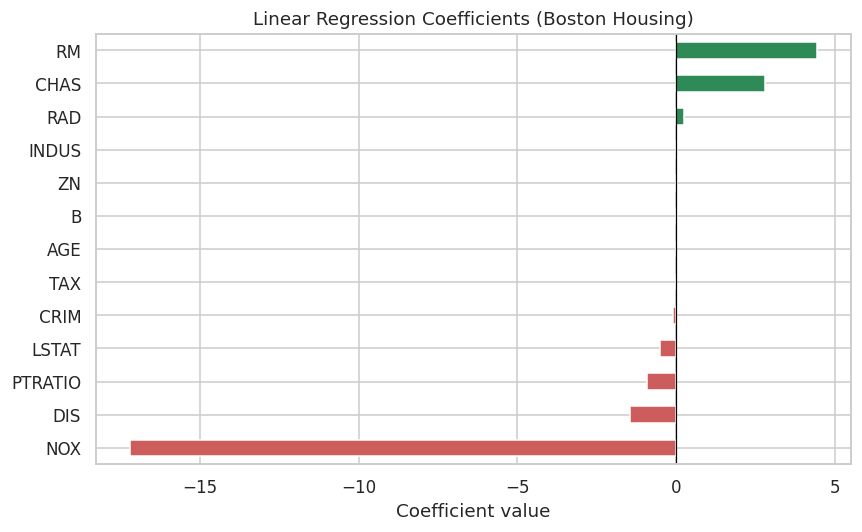

In [5]:
# Interpret coefficients (sorted by magnitude)
coef = pd.Series(model.coef_, index=X.columns).sort_values()
print("Intercept:", round(model.intercept_, 3))
print("\nCoefficients (effect on MEDV per unit feature change):")
print(coef.round(3))

plt.figure(figsize=(8, 5))
coef.plot(kind='barh', color=np.where(coef > 0, 'seagreen', 'indianred'))
plt.title("Linear Regression Coefficients (Boston Housing)")
plt.xlabel("Coefficient value"); plt.axvline(0, color='black', lw=0.8)
plt.tight_layout()
plt.savefig(OUT / "reg_coefficients.png", bbox_inches='tight')
plt.show()

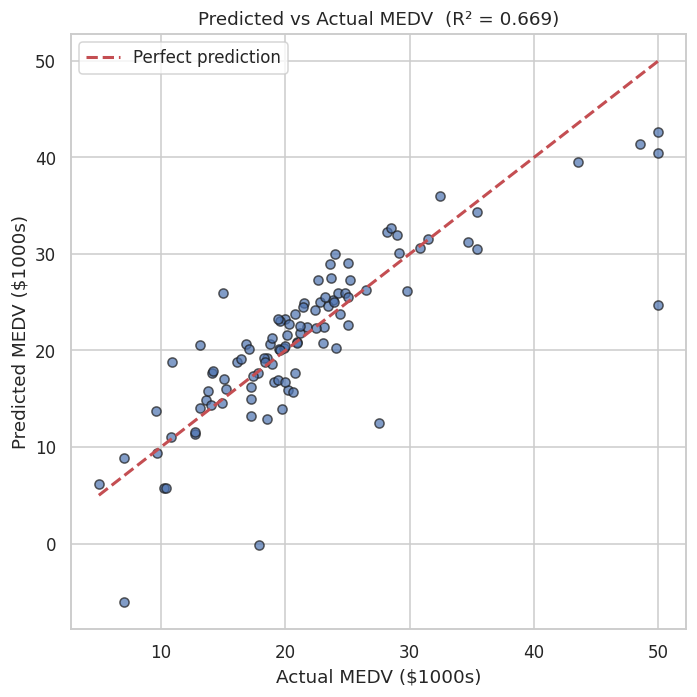

In [6]:
# Predicted vs Actual
plt.figure(figsize=(6.5, 6.5))
plt.scatter(y_test, y_pred, alpha=0.7, edgecolor='k')
lims = [y.min(), y.max()]
plt.plot(lims, lims, 'r--', lw=2, label='Perfect prediction')
plt.title(f"Predicted vs Actual MEDV  (R² = {r2:.3f})")
plt.xlabel("Actual MEDV ($1000s)"); plt.ylabel("Predicted MEDV ($1000s)")
plt.legend()
plt.tight_layout()
plt.savefig(OUT / "reg_pred_vs_actual.png", bbox_inches='tight')
plt.show()

**Regression summary:** the model explains ~67% of variance in test home prices
(R² ≈ 0.67). `RM` (rooms per dwelling) has a strong **positive** effect while `LSTAT`
(% lower-status population) and `NOX` (pollution) have strong **negative** effects —
all intuitive drivers of home value.

---
## Task 2 — Time Series Analysis

**Dataset:** `2) Stock Prices Data Set.csv` (505 symbols, 2014–2017 daily OHLCV).
We analyze **AAPL** closing prices: plot the series, decompose into
trend/seasonality/residual, and overlay moving-average smoothing.

In [7]:
# Load only AAPL rows to keep memory light
stocks = pd.read_csv(DATA_DIR / "2) Stock Prices Data Set.csv",
                     parse_dates=['date'])
aapl = (stocks[stocks['symbol'] == 'AAPL']
        .sort_values('date')
        .set_index('date'))
print("AAPL rows:", len(aapl), "| range:", aapl.index.min().date(), "->", aapl.index.max().date())
aapl[['open','high','low','close','volume']].head()

AAPL rows: 1007 | range: 2014-01-02 -> 2017-12-29


,open,high,low,close,volume
date,,,,,
2014-01-02,79.3828,79.5756,78.8601,79.0185,58791957
2014-01-03,78.9799,79.0999,77.2042,77.2828,98303870
2014-01-06,76.7785,78.1142,76.2285,77.7042,103359151
2014-01-07,77.7599,77.9942,76.8464,77.1481,79432766
2014-01-08,76.9728,77.9371,76.9556,77.6371,64686685


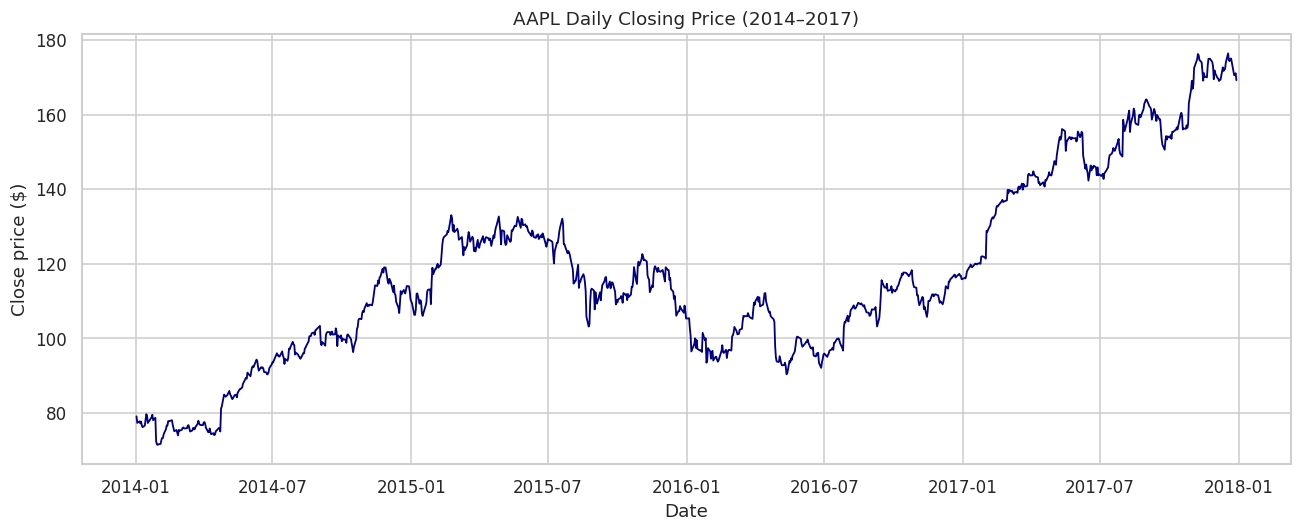

In [8]:
# Plot the raw closing-price series
plt.figure(figsize=(12, 5))
plt.plot(aapl.index, aapl['close'], color='navy', lw=1.2)
plt.title("AAPL Daily Closing Price (2014–2017)")
plt.xlabel("Date"); plt.ylabel("Close price ($)")
plt.tight_layout()
plt.savefig(OUT / "ts_close_series.png", bbox_inches='tight')
plt.show()

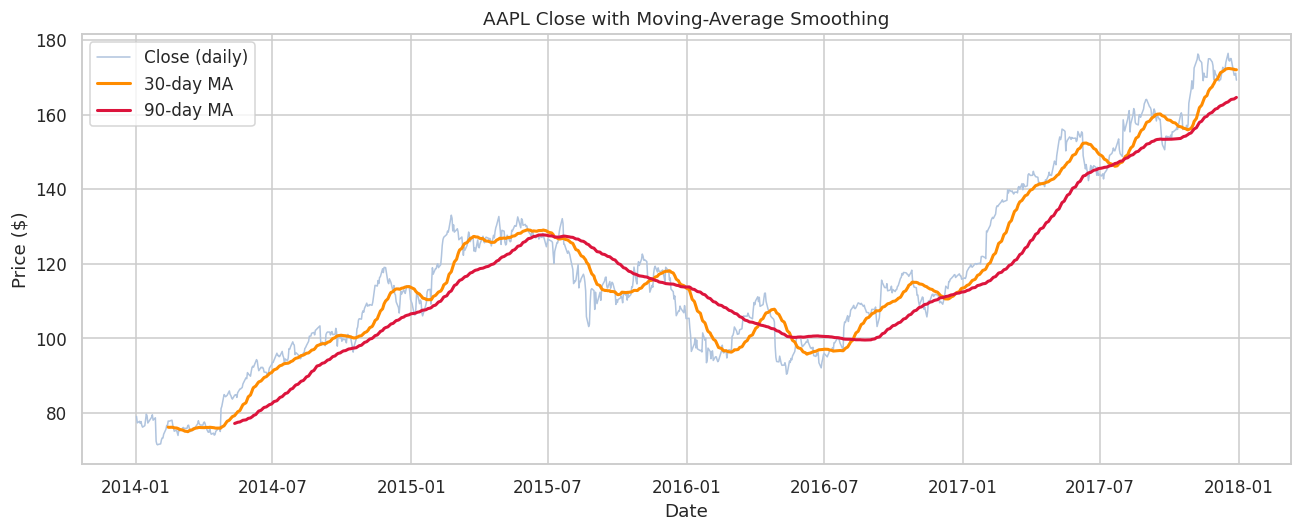

In [9]:
# Moving-average smoothing (30- and 90-day)
close = aapl['close']
ma30 = close.rolling(30).mean()
ma90 = close.rolling(90).mean()

plt.figure(figsize=(12, 5))
plt.plot(close.index, close, color='lightsteelblue', lw=1, label='Close (daily)')
plt.plot(ma30.index, ma30, color='darkorange', lw=2, label='30-day MA')
plt.plot(ma90.index, ma90, color='crimson', lw=2, label='90-day MA')
plt.title("AAPL Close with Moving-Average Smoothing")
plt.xlabel("Date"); plt.ylabel("Price ($)"); plt.legend()
plt.tight_layout()
plt.savefig(OUT / "ts_moving_average.png", bbox_inches='tight')
plt.show()

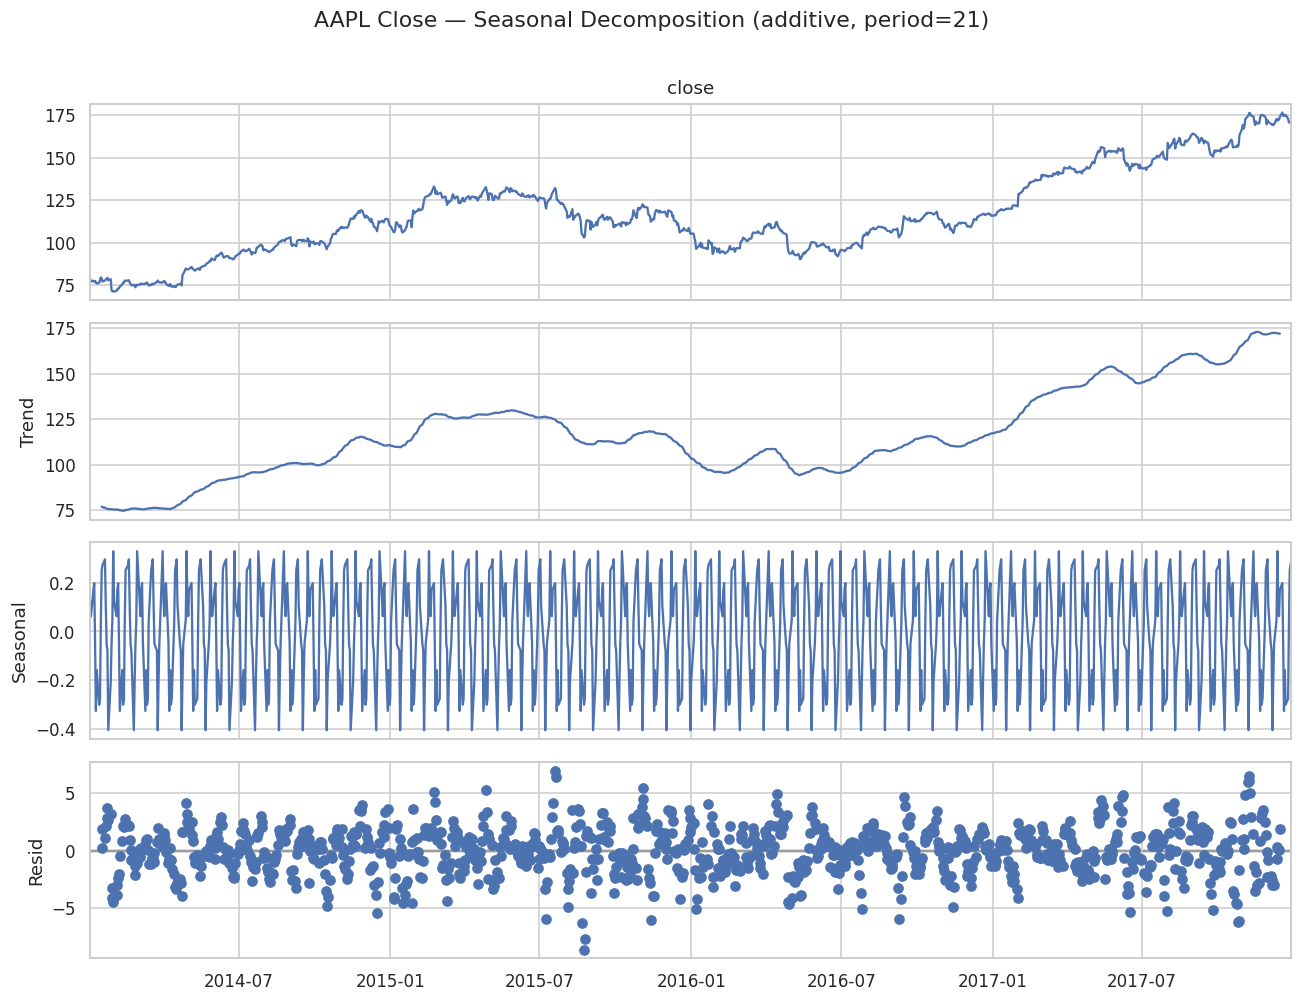

In [10]:
# Decompose into trend, seasonality and residual.
# Use business-day frequency and a ~21-trading-day (monthly) seasonal period.
from statsmodels.tsa.seasonal import seasonal_decompose

close_bd = close.asfreq('B').interpolate()   # regular business-day index
result = seasonal_decompose(close_bd, model='additive', period=21)

fig = result.plot()
fig.set_size_inches(12, 9)
fig.suptitle("AAPL Close — Seasonal Decomposition (additive, period=21)", y=1.01)
fig.tight_layout()
fig.savefig(OUT / "ts_decomposition.png", bbox_inches='tight')
plt.show()

**Time-series summary:** AAPL shows a clear long-term **upward trend** with a strong
2015 dip and recovery. The 30/90-day moving averages smooth out daily noise and confirm
the trend; the decomposition isolates a small repeating seasonal component and leaves
residual noise around the trend.

---
## Task 3 — Clustering Analysis (K-Means)

**Dataset:** `1) iris.csv`. Goal: standardize features, choose *k* via the elbow method,
fit K-Means, visualize clusters, and compare to the true species.

In [11]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

iris = pd.read_csv(DATA_DIR / "1) iris.csv")
features = ['sepal_length','sepal_width','petal_length','petal_width']
X = iris[features].values
Xs = StandardScaler().fit_transform(X)   # standardize before distance-based clustering
print("Standardized feature matrix:", Xs.shape)

Standardized feature matrix: (150, 4)


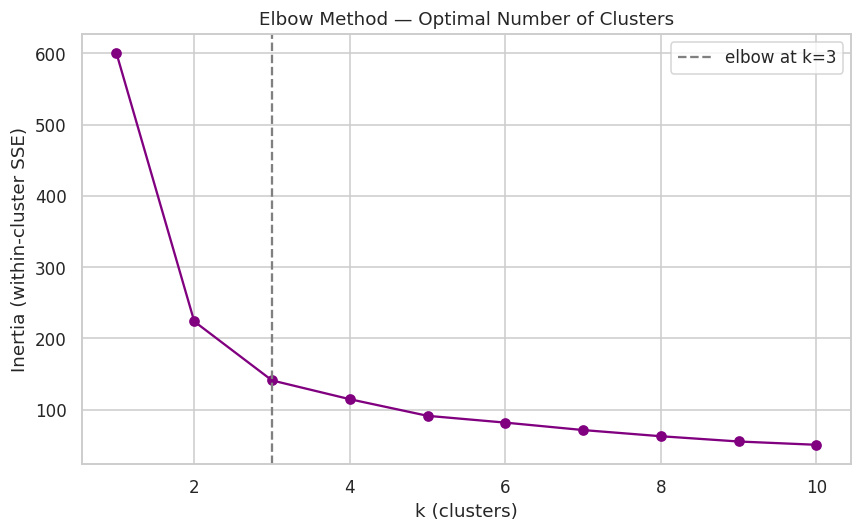

In [12]:
# Elbow method — inertia across k = 1..10
inertias = []
ks = range(1, 11)
for k in ks:
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(Xs)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(list(ks), inertias, 'o-', color='purple')
plt.axvline(3, color='gray', ls='--', label='elbow at k=3')
plt.title("Elbow Method — Optimal Number of Clusters")
plt.xlabel("k (clusters)"); plt.ylabel("Inertia (within-cluster SSE)"); plt.legend()
plt.tight_layout()
plt.savefig(OUT / "cluster_elbow.png", bbox_inches='tight')
plt.show()

In [13]:
# Fit K-Means with the chosen k = 3
km = KMeans(n_clusters=3, random_state=42, n_init=10)
iris['cluster'] = km.fit_predict(Xs)

# Cross-tabulate clusters against the true species
print("Cluster vs true species:")
print(pd.crosstab(iris['cluster'], iris['species']))

from sklearn.metrics import silhouette_score
print("\nSilhouette score:", round(silhouette_score(Xs, iris['cluster']), 3))

Cluster vs true species:
species  setosa  versicolor  virginica
cluster                               
0             0          39         14
1            50           0          0
2             0          11         36

Silhouette score: 0.459


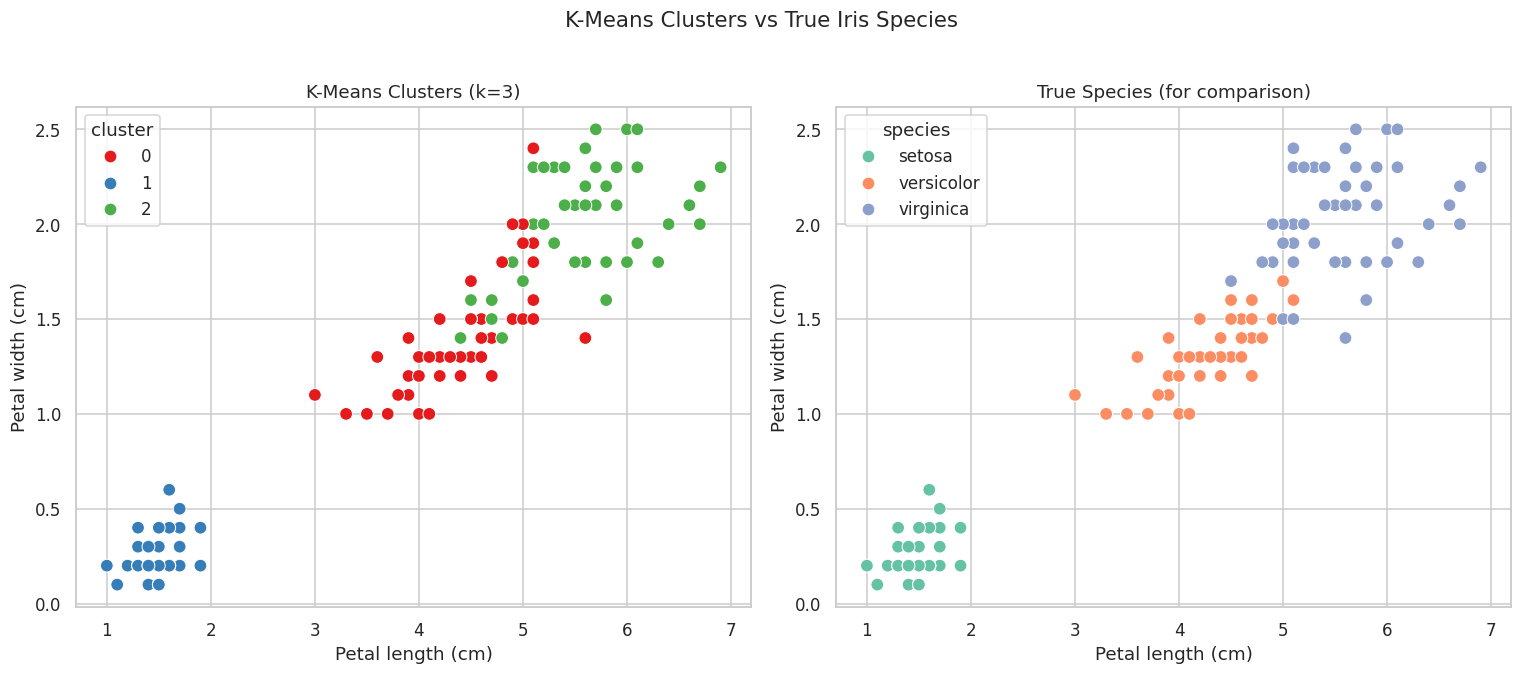

In [14]:
# Visualize clusters on the petal plane (most separable features)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sns.scatterplot(data=iris, x='petal_length', y='petal_width',
                hue='cluster', palette='Set1', s=70, ax=axes[0])
# plot cluster centers (inverse-transform back to original petal scale)
axes[0].set_title("K-Means Clusters (k=3)")
sns.scatterplot(data=iris, x='petal_length', y='petal_width',
                hue='species', palette='Set2', s=70, ax=axes[1])
axes[1].set_title("True Species (for comparison)")
for a in axes:
    a.set_xlabel("Petal length (cm)"); a.set_ylabel("Petal width (cm)")
fig.suptitle("K-Means Clusters vs True Iris Species", y=1.02, fontsize=14)
fig.tight_layout()
fig.savefig(OUT / "cluster_scatter.png", bbox_inches='tight')
plt.show()

**Clustering summary:** the elbow appears at **k = 3**, matching the three species.
K-Means recovers *setosa* perfectly and separates *versicolor*/*virginica* with only a few
boundary mismatches (silhouette ≈ 0.46) — strong unsupervised agreement with the labels.

---
### Level 2 complete ✅
All figures saved in `outputs/`.